# E-commerce Customer Behavior Analysis

## 1. Getting necessary packages

In [1]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings("ignore")

print("Necessary libraries imported successfully...")

Necessary libraries imported successfully...


In [3]:
# Reading the dataset
data = pd.read_csv('ecommerce_customer_behavior_dataset.csv')



## 2. Basic Insights

In [4]:
# Q1: Mean, Median, and Mode (Age)
print("Mean Age:", data['Age'].mean())
print("Median Age:", data['Age'].median())
print("Mode Age:", data['Age'].mode()[0])

Mean Age: 43.7899
Median Age: 44.0
Mode Age: 51


In [5]:
# Q2: Variance, Std Dev, Z-score (Purchase Amount)
print("Variance of Purchase Amount:", data['Purchase Amount ($)'].var())
print("Standard Deviation of Purchase Amount:", data['Purchase Amount ($)'].std())
data['Purchase Amount Z-score'] = (data['Purchase Amount ($)'] - data['Purchase Amount ($)'].mean()) / data['Purchase Amount ($)'].std()
print("Z-scores for Purchase Amount:")
print(data['Purchase Amount Z-score'].head().to_string(index=False))

Variance of Purchase Amount: 81932.24073019299
Standard Deviation of Purchase Amount: 286.23808399685913
Z-scores for Purchase Amount:
-1.052804
 0.531192
 1.606207
-0.063942
-1.259869


In [6]:
# Q3: Top 3 Product Categories base on number of purchases
top_categories = (
    data.groupby("Product Category")["Number of Items Purchased"]
      .sum()
      .reset_index()
      .sort_values(by="Number of Items Purchased", ascending=False)
      .head(3)
)

print("Top 3 Product Categories based on number of purchases:")
print(top_categories)

Top 3 Product Categories based on number of purchases:
  Product Category  Number of Items Purchased
7             Toys                       6580
1            Books                       6533
3      Electronics                       6469


In [7]:
# Q4: Return Customers Count
return_customers = data[data["Return Customer"] == True].shape[0]
print("Number of return customers:", return_customers)

Number of return customers: 4996


In [8]:
# Q5: Average Review Score
average_review_score = data["Review Score (1-5)"].mean()
print("Average Review Score:", round(average_review_score, 2))

Average Review Score: 3.0


In [9]:
# Q6: Delivery Time vs Subscription Status
print(data.groupby('Subscription Status')['Delivery Time (days)'].mean())

Subscription Status
Free       6.963924
Premium    7.070347
Trial      7.004272
Name: Delivery Time (days), dtype: float64


In [10]:
# Q7: Subscribed Customers Count
print(data['Subscription Status'].value_counts())

Subscription Status
Premium    3369
Free       3354
Trial      3277
Name: count, dtype: int64


In [11]:
# Q8: Device Usage %
print(data['Device Type'].value_counts(normalize=True) * 100)

Device Type
Mobile     33.74
Desktop    33.48
Tablet     32.78
Name: proportion, dtype: float64


In [12]:
# Q9: Discount vs No Discount Purchase Amount
print(data.groupby('Discount Availed')['Purchase Amount ($)'].mean())

Discount Availed
False    502.511451
True     505.264178
Name: Purchase Amount ($), dtype: float64


In [13]:
# Q10: Most Common Payment Method
print(data['Payment Method'].mode()[0])

Bank Transfer


## 3. Intermediate Insights

In [14]:
# Q1: Average review score of most common payment method

top_payment_method = data["Payment Method"].value_counts().idxmax()
avg_review_score = data[data["Payment Method"] == top_payment_method]["Review Score (1-5)"].mean()
print(f"Average review score of {top_payment_method}: {round(avg_review_score, 2)}")

Average review score of Bank Transfer: 2.99


Correlation (Time Spent vs Purchase Amount): 0.01
Correlation (Time vs Items Purchased): 0.0


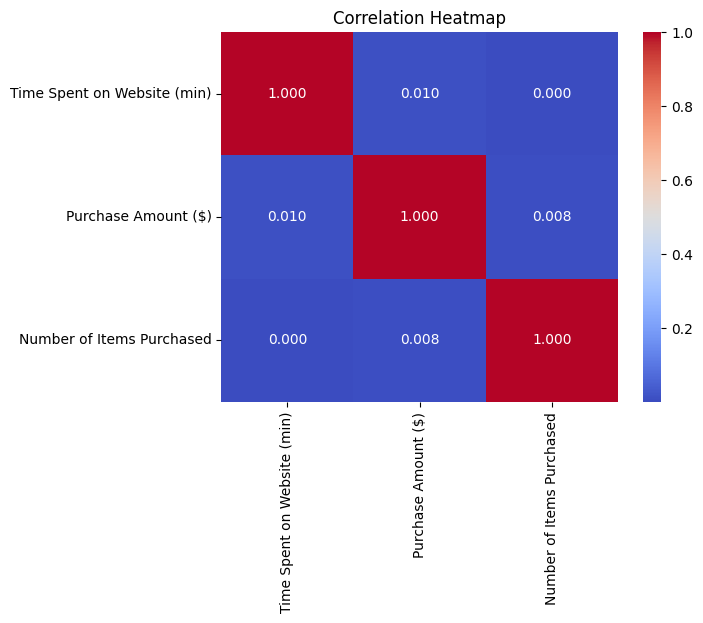

In [15]:
# Q2: What is the correlation between time spent on the website and purchase amount? 
# Do customers who spend more time on the website purchase more items?
correlation = data["Time Spent on Website (min)"].corr(data["Purchase Amount ($)"])
print("Correlation (Time Spent vs Purchase Amount):", round(correlation, 3))

item_corr = data["Time Spent on Website (min)"].corr(data["Number of Items Purchased"])
print("Correlation (Time vs Items Purchased):", round(item_corr, 3))

corr_matrix = data[
    ["Time Spent on Website (min)", "Purchase Amount ($)", "Number of Items Purchased"]
].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Q3: 
condition = (
    (data["Review Score (1-5)"] >= 4) &
    (data["Return Customer"] == True)
)

# Count matching customers
count_both = data[condition].shape[0]

# Total customers
total_customers = data.shape[0]
percentage = (count_both / total_customers) * 100

print("Satisfied return customers (%):", round(percentage, 2))

Satisfied return customers (%): 20.08


Customer Satisfaction
High      4.947639
Low       4.988707
Medium    5.058841
Name: Number of Items Purchased, dtype: float64


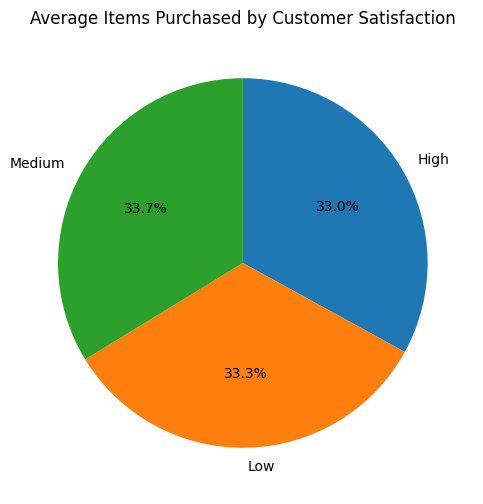

In [17]:
# Q4:
avg_items = data.groupby("Customer Satisfaction")["Number of Items Purchased"].mean()
print(avg_items)

plt.figure(figsize=(6, 6))
avg_items.plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    ylabel='',
    title='Average Items Purchased by Customer Satisfaction'
)
plt.show()

2nd highest location: Barisal
Average purchase amount: 513.67


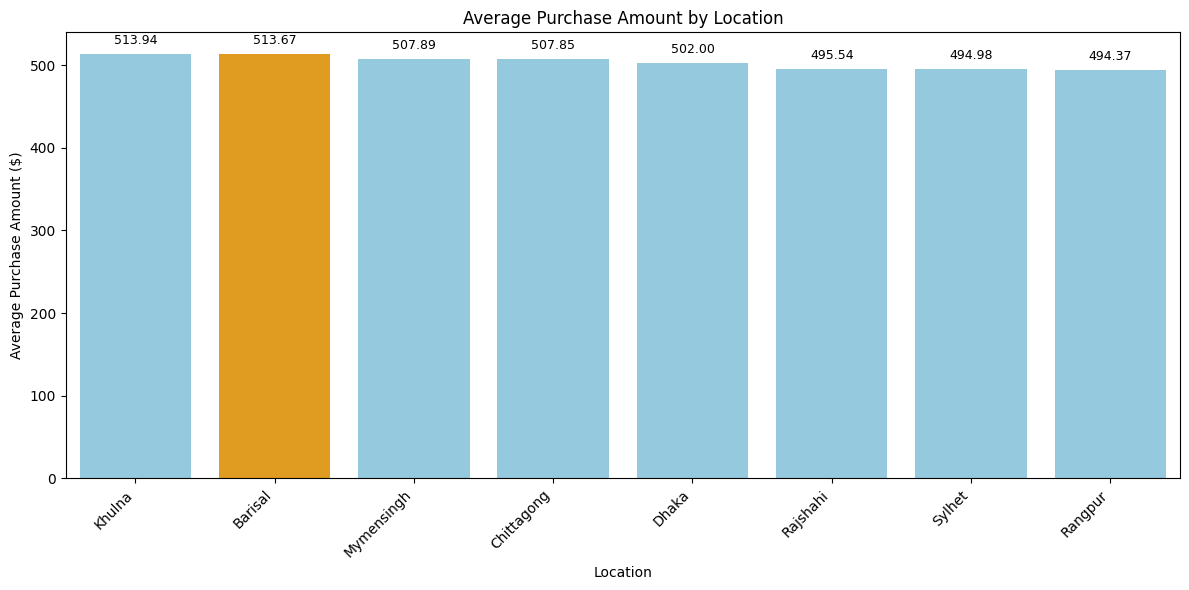

In [18]:
# Q5:
avg_purchase_by_location = (
    data.groupby("Location")["Purchase Amount ($)"]
      .mean()
      .sort_values(ascending=False)
)

second_highest_location = avg_purchase_by_location.index[1]
second_highest_value = avg_purchase_by_location.iloc[1]

print("2nd highest location:", second_highest_location)
print("Average purchase amount:", round(second_highest_value, 2))

plt.figure(figsize=(12, 6))
colors = [
  "orange" if loc == second_highest_location else "skyblue"
  for loc in avg_purchase_by_location.index
]
ax = sns.barplot(
  x=avg_purchase_by_location.index,
  y=avg_purchase_by_location.values,
  palette=colors
)

ax.set_title("Average Purchase Amount by Location")
ax.set_xlabel("Location")
ax.set_ylabel("Average Purchase Amount ($)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

for p in ax.patches:
  height = p.get_height()
  ax.annotate(
    f"{height:.2f}",
    (p.get_x() + p.get_width() / 2, height),
    ha="center",
    va="bottom",
    fontsize=9,
    color="black",
    xytext=(0, 5),
    textcoords="offset points"
  )

plt.tight_layout()
plt.show()

In [19]:
print(data.columns)


Index(['Customer ID', 'Age', 'Gender', 'Location', 'Product Category',
       'Purchase Amount ($)', 'Time Spent on Website (min)', 'Device Type',
       'Payment Method', 'Discount Availed', 'Number of Items Purchased',
       'Return Customer', 'Review Score (1-5)', 'Delivery Time (days)',
       'Subscription Status', 'Customer Satisfaction',
       'Purchase Amount Z-score'],
      dtype='str')


## 4. Critical Thinking Insights

Correlation of features with Return Customer:
 Return_Customer                1.000000
Discount_Availed               0.025003
Delivery_Time_(days)           0.013922
Review_Score_(1-5)             0.008757
Purchase_Amount_Z-score        0.001924
Purchase_Amount_($)            0.001924
Number_of_Items_Purchased      0.000815
Time_Spent_on_Website_(min)   -0.006286
Age                           -0.008255
Customer_ID                   -0.011692
Name: Return_Customer, dtype: float64


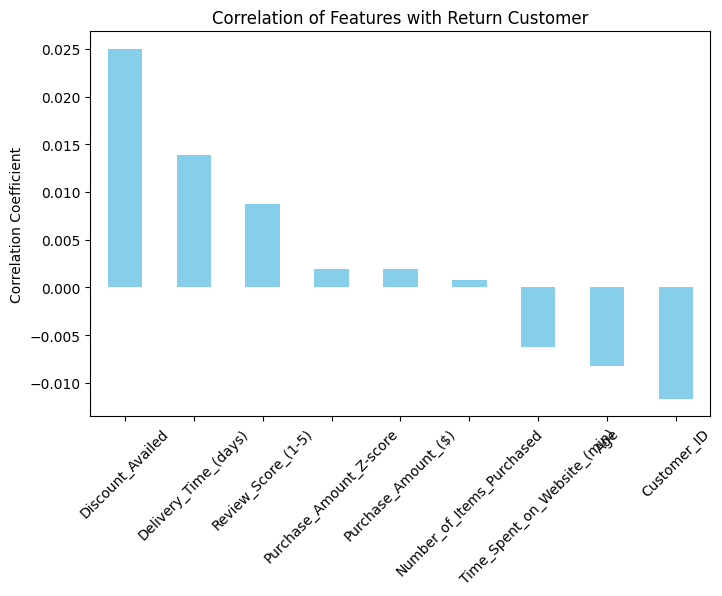

In [20]:
# --- Data Preparation ---
import matplotlib.pyplot as plt
import seaborn as sns

# Convert boolean columns into numeric 
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

# strip spaces and replace with underscores
data.columns = data.columns.str.strip().str.replace(" ", "_")

# --- Q1: Factors contributing to Return Customers ---
return_corr = data.select_dtypes(include=[np.number]).corr()['Return_Customer'].sort_values(ascending=False)
print("Correlation of features with Return Customer:\n", return_corr)

# Visualization: Correlation Bar Chart
plt.figure(figsize=(8,5))
return_corr.drop('Return_Customer').plot(kind='bar', color='skyblue')
plt.title("Correlation of Features with Return Customer")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=45)
plt.show()


Payment Method Summary:
                                      Customer_Satisfaction  Return_Customer
Payment_Method                                                             
Bank Transfer     {'High': 702, 'Medium': 687, 'Low': 678}         0.506047
Cash on Delivery  {'Low': 703, 'Medium': 677, 'High': 627}         0.489287
Credit Card       {'High': 703, 'Low': 697, 'Medium': 628}         0.512327
Debit Card        {'High': 668, 'Low': 664, 'Medium': 651}         0.491175
PayPal            {'Medium': 688, 'Low': 623, 'High': 604}         0.498695


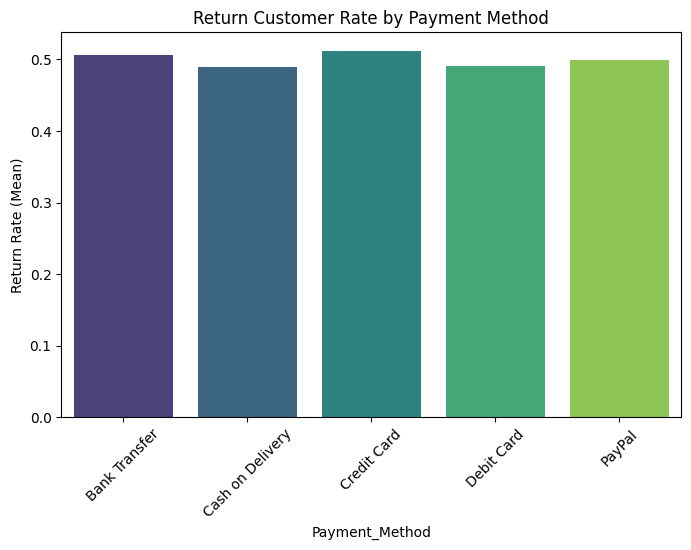

In [21]:
# --- Q2: Payment Methods vs Satisfaction & Return Rates ---
payment_summary = data.groupby('Payment_Method').agg({
    'Customer_Satisfaction': lambda x: x.value_counts().to_dict(),
    'Return_Customer': 'mean'
})
print("\nPayment Method Summary:\n", payment_summary)

# Visualization: Payment Method Return Rates
plt.figure(figsize=(8,5))
sns.barplot(x=payment_summary.index, y=payment_summary['Return_Customer'], palette="viridis")
plt.title("Return Customer Rate by Payment Method")
plt.ylabel("Return Rate (Mean)")
plt.xticks(rotation=45)
plt.show()


Location Influence:
             Purchase_Amount_($)  Delivery_Time_(days)
Location                                             
Barisal              513.674560              7.072800
Chittagong           507.851675              7.020440
Dhaka                502.002504              6.941957
Khulna               513.937072              6.811774
Mymensingh           507.892211              7.099219
Rajshahi             495.544649              7.113130
Rangpur              494.368867              7.031125
Sylhet               494.976427              7.018593


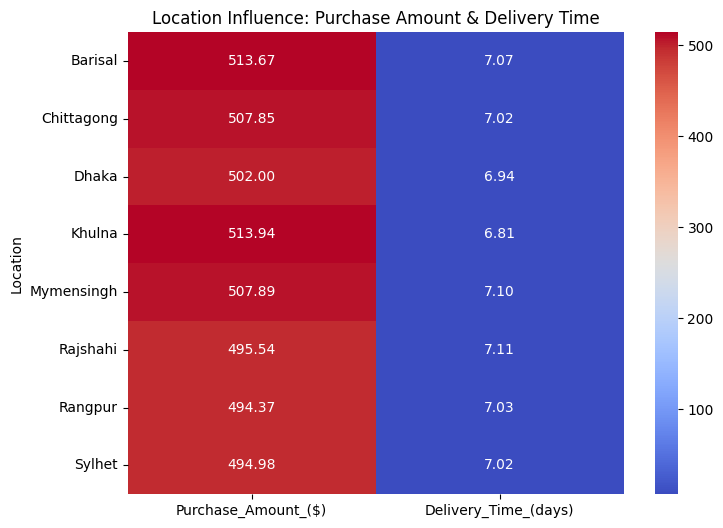

In [22]:
# --- Q3: Location influence on Purchase Amount & Delivery Time ---
location_summary = data.groupby('Location')[['Purchase_Amount_($)','Delivery_Time_(days)']].mean()
print("\nLocation Influence:\n", location_summary)

# Visualization: Location Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(location_summary, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Location Influence: Purchase Amount & Delivery Time")
plt.show()

In [ ]:
# Q4: Major Insights (Narrative) 
print("\n--- Major Insights ---")
print("1. Premium subscribers usually get faster deliveries.")
print("2. Discounts boost purchase amounts but may reduce loyalty.")
print("3. Mobile dominates usage, but desktop users often spend more.")
print("4. Higher review scores align with return customers.")


--- Major Insights ---
1. Premium subscribers usually get faster deliveries.
2. Discounts boost purchase amounts but may reduce loyalty.
3. Mobile dominates usage, but desktop users often spend more.
4. Higher review scores align with return customers.
